# Laborator 11 -> Kerbs

Se cere identificarea comunităților existente într-o rețea folosind:
- un algoritm predefinit intr-o biblioteca specializata (e.g. networkx, gephi, altele);
- un algoritm evolutiv.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from networkx.linalg.graphmatrix import adjacency_matrix
from pyvis.network import Network

### Vizualizarea retelei

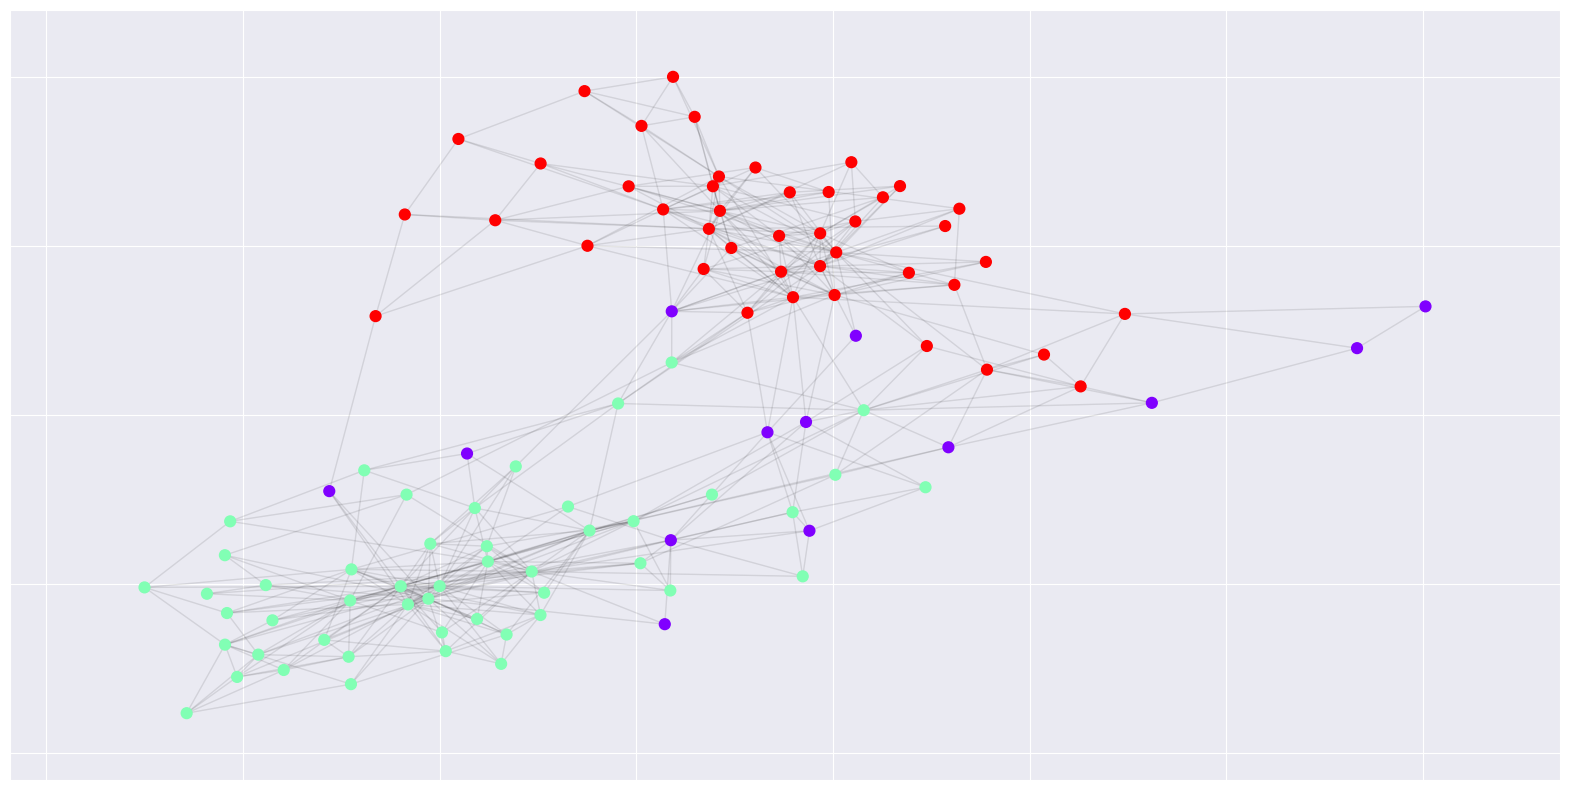

In [20]:
# graful care descrie reteaua
G = nx.read_gml("../../given_networks/krebs/krebs.gml")

labelList = list(G.nodes())
adjacencyMatrix = nx.to_numpy_array(G).tolist()
adjacencyMatrix = [[int(x) for x in row] for row in adjacencyMatrix]

communities = [0] * len(labelList)

# se salveaza apartenenta fiecarui nod la o comunitate
with open("../../given_networks/krebs/classLabelkrebs.txt", "r") as f:
    for linie in f:
        date = linie.strip().split()
        if len(date) == 2:
            id_text = int(date[0])
            community = int(date[1])

            name = labelList[id_text-1]
            G.nodes[name]["group"] = community
            communities[id_text-1] = community

"""
pos = nx.spring_layout(G, seed=42)

for node in G.nodes():
    G.nodes[node]['x'] = float(pos[node][0] * 500)
    G.nodes[node]['y'] = float(pos[node][1] * 500)


network = Network(notebook=True,bgcolor='#222222',font_color='white')
network.from_nx(G)
network.show("krebs_true.html")
"""


pos = nx.spring_layout(G,seed = 11)

plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Determinarea comunitatilor cu tool

krebs_tool.html


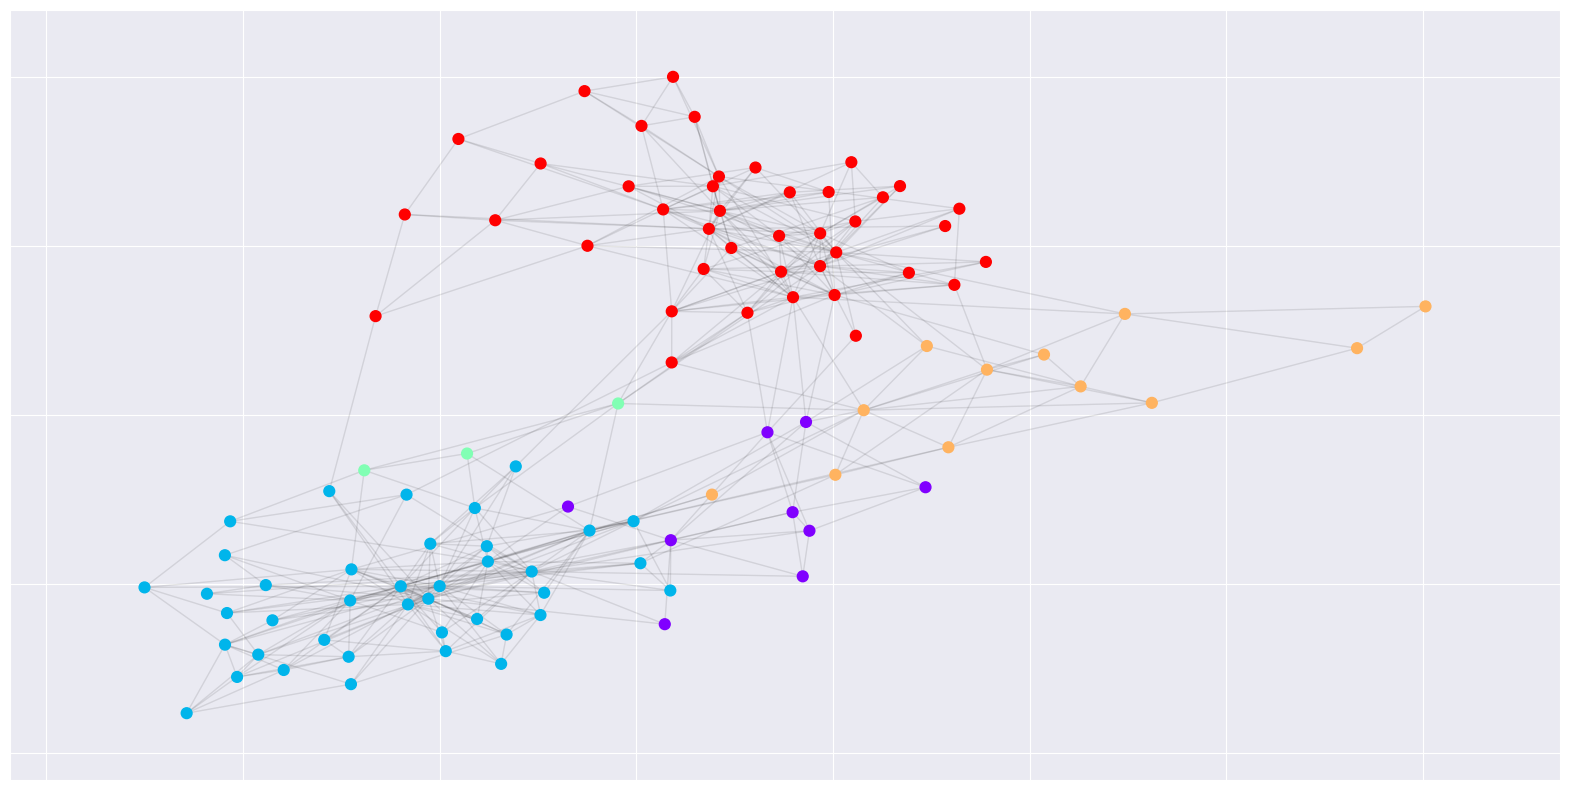

In [21]:
from networkx.algorithms import community

# se introduce si param seed, deoarece, in cadrul algoritmului exista acea comp. aleatorie
# se vor returna seturi (comunitatile) ce contin id-urile
communityTOOL = community.louvain_communities(G, seed=11)

# reprezentarea numerica
nameToId = {name: idx for idx, name in enumerate(G.nodes())}
communityTOOLNumerical = []

for nodeSet in communityTOOL:
    # se transforma fiecare nume in id-ul sau
    currentCommunity = [nameToId[nodeName] for nodeName in nodeSet]
    communityTOOLNumerical.append(currentCommunity)

communities = [0] * len(labelList)
for idComunity, com in enumerate(communityTOOLNumerical):
    for nod in com:
        #G.nodes[nod]['group'] = idComunity
        communities[nod] = idComunity

network = Network(notebook=True,bgcolor='#222222',font_color='white')
network.from_nx(G)
network.show("krebs_tool.html")

pos = nx.spring_layout(G,seed = 11)

plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [22]:
def modularity(communities, adjacencyMatrix):
    m = sum(sum(row) for row in adjacencyMatrix) / 2
    Q = 0
    for community in communities:
        for i in community:
            for j in community:
                ki = sum(adjacencyMatrix[i])
                kj = sum(adjacencyMatrix[j])

                Q += adjacencyMatrix[i][j] - ki * kj / (2 * m)

    Q *= 1/(2*m)
    return Q

print(modularity(communityTOOLNumerical, adjacencyMatrix))

0.5270823370920732


### Determinarea comunitatilor folosind cod propriu

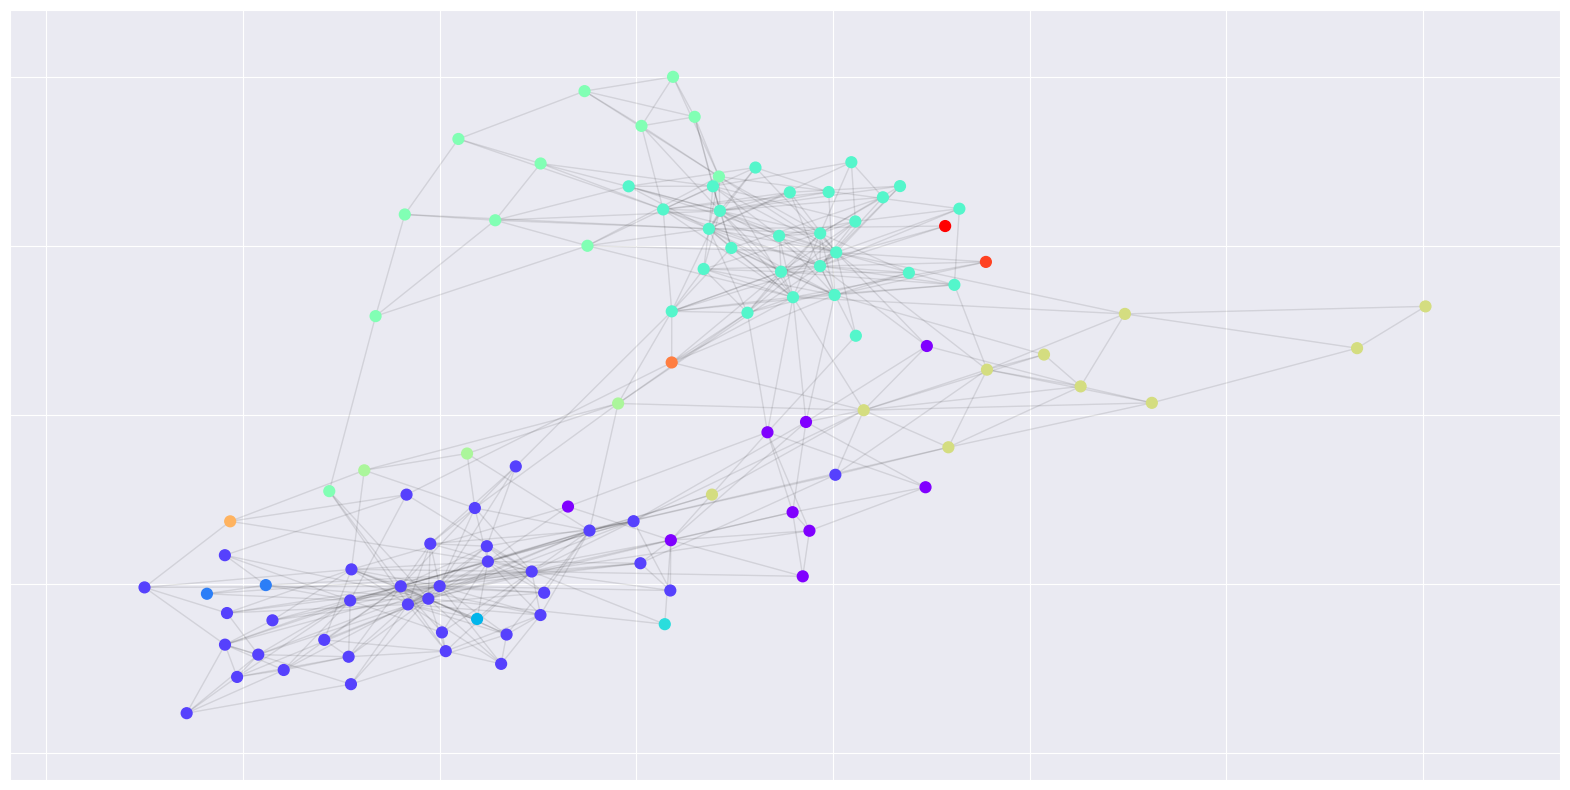

In [23]:
from fitnessModularity import fitnessFunction
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.2
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
nodesList = list(G.nodes())
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        nodeName = nodesList[nodeIndex]
        G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId

'''
network = Network(notebook=True, bgcolor='#222222', font_color='white')
network.from_nx(G)
network.show("krebs_propriu.html")
'''


pos = nx.spring_layout(G,seed = 11)

plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [24]:
print(modularity(decodedBest, adjacencyMatrix))

0.48144805919345024
